In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("cleaned_supply_chain_data.csv")

# Basic Overview

In [3]:
df.head(5)

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred,Year,Month,Month_Name,Quarter
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39000,1,2025,10,October,4
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92000,1,2024,4,April,2
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54000,0,2024,1,January,1
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,49.85375,1,2024,10,October,4
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50000,1,2024,9,September,3


In [8]:
df.shape

(5000, 18)

In [9]:
df.describe()

,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred,Year,Month,Quarter
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,7704.063888,246.252052,2.854552,5.076900,0.754387,14.602983,0.612600,2024.509000,6.564400,2.523000
std,4199.687885,142.522591,0.959533,2.877832,0.144363,15.861364,0.487205,0.499969,3.463387,1.124333
min,500.170000,1.030000,1.200000,0.000000,0.500000,0.500000,0.000000,2024.000000,1.000000,1.000000
25%,4036.010000,124.330000,2.020000,2.600000,0.629000,2.110000,0.000000,2024.000000,4.000000,2.000000
50%,7750.125000,243.500000,2.840000,5.100000,0.757000,8.245000,1.000000,2025.000000,7.000000,3.000000
75%,11347.462500,366.955000,3.710000,7.500000,0.879000,21.207500,1.000000,2025.000000,10.000000,4.000000
max,14995.910000,499.750000,4.500000,10.000000,1.000000,49.853750,1.000000,2025.000000,12.000000,4.000000


# Check the missing values

In [10]:
df.isnull().sum()

Shipment_ID                  0
Date                         0
Origin_Port                  0
Destination_Port             0
Transport_Mode               0
Product_Category             0
Distance_km                  0
Weight_MT                    0
Fuel_Price_Index             0
Geopolitical_Risk_Score      0
Weather_Condition            0
Carrier_Reliability_Score    0
Lead_Time_Days               0
Disruption_Occurred          0
Year                         0
Month                        0
Month_Name                   0
Quarter                      0
dtype: int64

There is no any missing values. 

In [11]:
df['Date'] = pd.to_datetime(df['Date'])

# Univariate Analysis

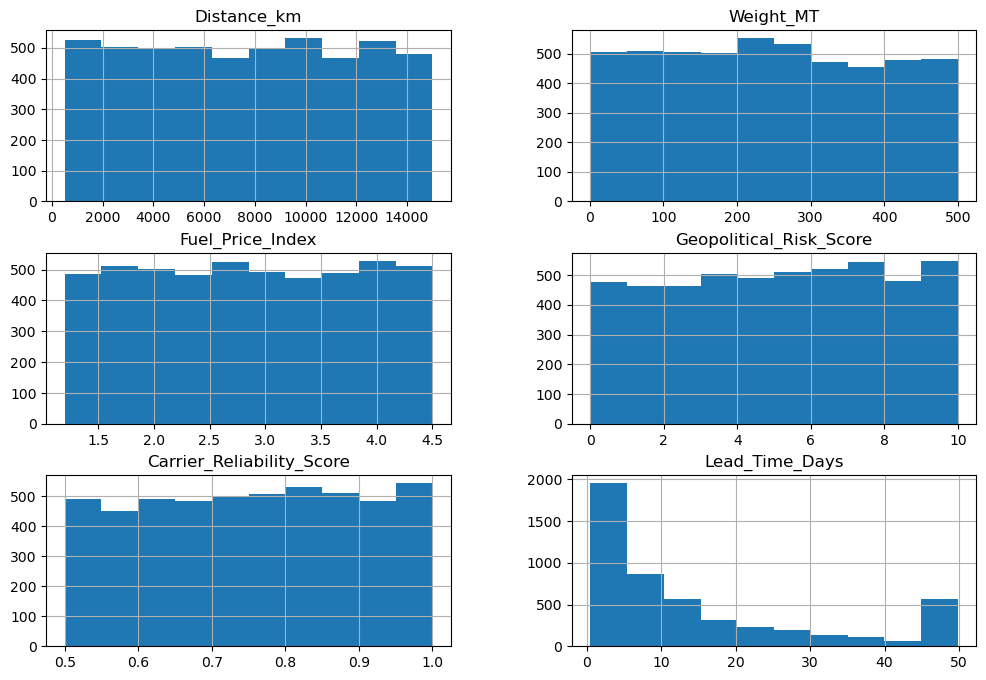

In [12]:
num_cols = ['Distance_km', 'Weight_MT', 'Fuel_Price_Index',
            'Geopolitical_Risk_Score', 'Carrier_Reliability_Score',
            'Lead_Time_Days']

df[num_cols].hist(figsize=(12,8))
plt.show()

- The Lead Time days distribution shows that the majority of shipments are delivered within 0–10 days, indicating relatively fast delivery performance for most cases.

- The remaining variables do not exhibit any strong patterns or distinctive trends. Their distributions appear fairly uniform, suggesting that the data is evenly spread without significant skewness or concentration.

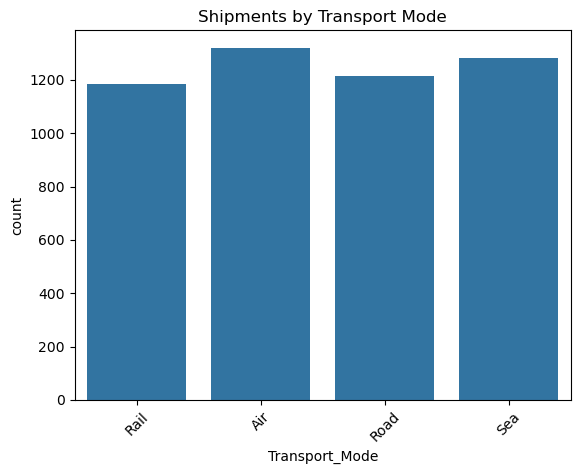

In [42]:
sns.countplot(data=df, x='Transport_Mode')
plt.xticks(rotation=45)
plt.title("Shipments by Transport Mode")
plt.show()


- The majority of goods are delivered via **air transport**, while **rail transport** accounts for the lowest share of deliveries.

- Overall, there are no significant differences observed among the four transport modes, as the distribution remains relatively balanced without any extreme variations.

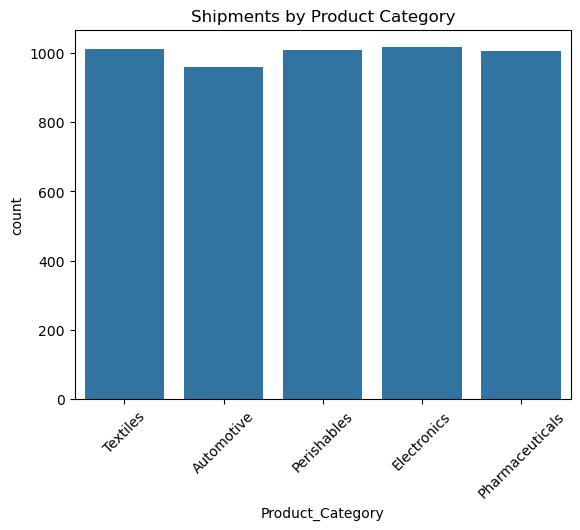

In [43]:
sns.countplot(data=df, x='Product_Category')
plt.title("Shipments by Product Category")
plt.xticks(rotation=45)
plt.show()


- **Electronic items** represent the highest number of deliveries among all product categories.

- Deliveries of **textiles, perishables, and pharmaceuticals** appear to be relatively similar in volume, with no significant differences observed between them.

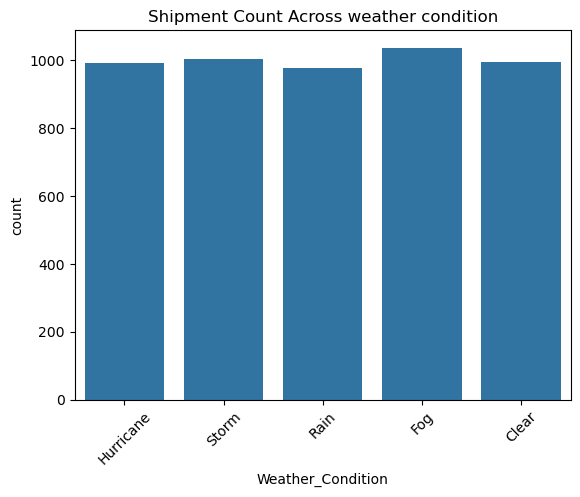

In [44]:
sns.countplot(data=df, x='Weather_Condition')
plt.xticks(rotation=45)
plt.title("Shipment Count Across weather condition")
plt.show()

- This chart illustrates the **weather conditions experienced during transit**.

- Among all conditions, **fog** is the most frequently encountered weather condition affecting shipments.

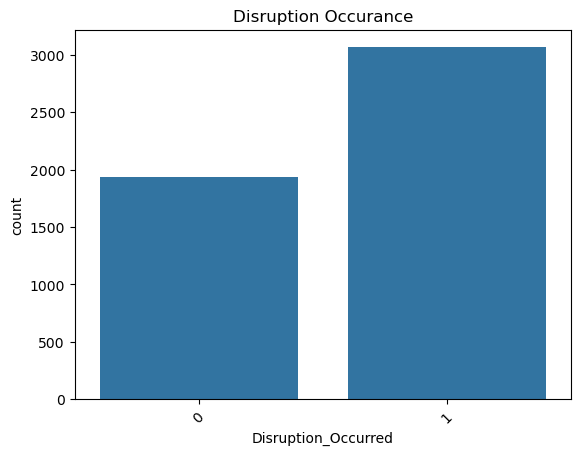

In [45]:
sns.countplot(data=df, x='Disruption_Occurred')
plt.xticks(rotation=45)
plt.title("Disruption Occurance")
plt.show()

- Approximately **2,000 shipments** were completed without any disruptions.

- In contrast, around **3,000 shipments** experienced disruptions during transit.

# Corelation Matrix

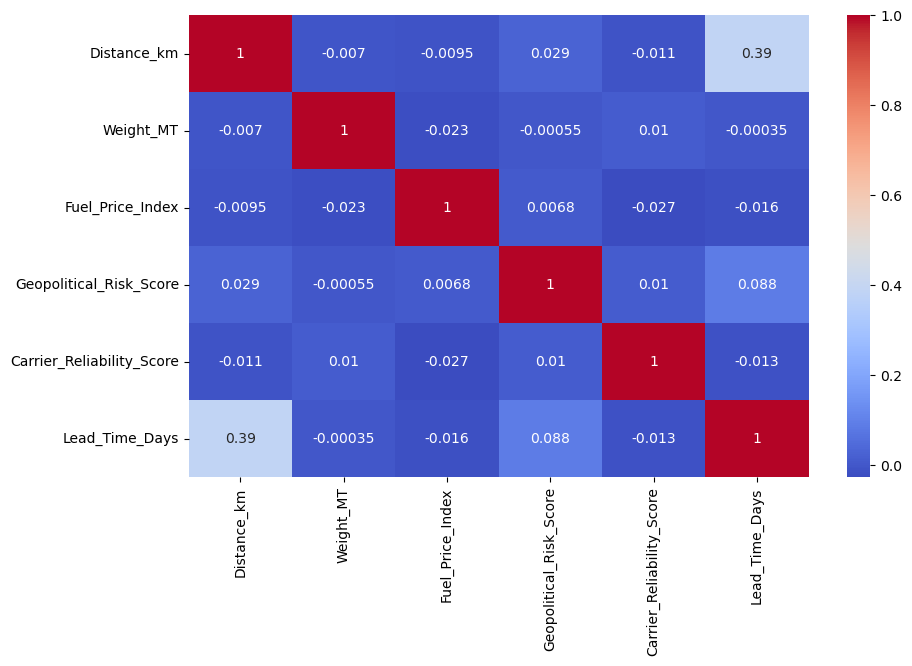

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

- The correlation matrix indicates that there are **no strong positive relationships** among the variables.

- Most correlations are weak, suggesting that the features are largely independent and do not significantly influence each other in a linear manner.

# Transport mode vs Disruption

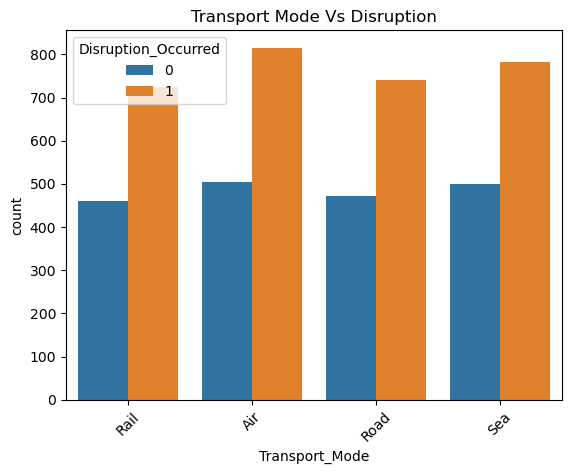

In [41]:
sns.countplot(data=df, x='Transport_Mode', hue='Disruption_Occurred')
plt.xticks(rotation=45)
plt.title("Transport Mode Vs Disruption")
plt.show()

- The highest number of disrupted shipments is observed in **air transport**, followed by **sea transport**.

- However, there are no significant differences in disruption occurrence across the four transport modes, as the distribution remains relatively similar.

# Weather Impact

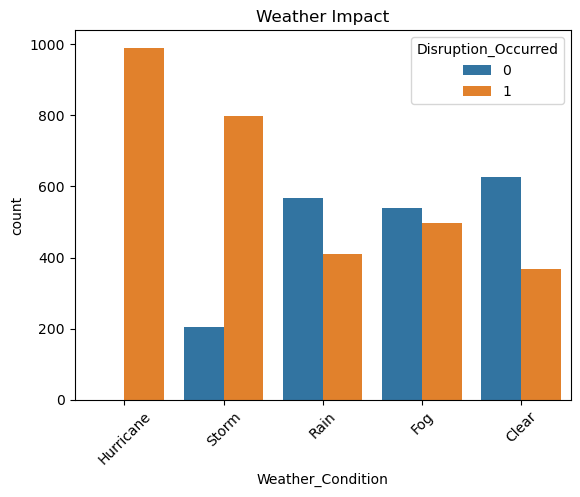

In [40]:
sns.countplot(data=df, x='Weather_Condition', hue='Disruption_Occurred')
plt.xticks(rotation=45)
plt.title("Weather Impact")
plt.show()

- The majority of shipment disruptions are caused by **hurricanes** and **storms**.

- Other causes contribute significantly less in comparison and remain well behind these two categories.

# Top Origin Ports

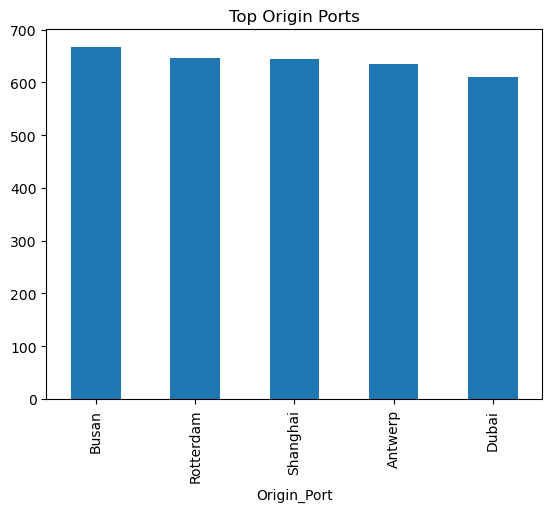

In [32]:
df['Origin_Port'].value_counts().head(5).plot(kind='bar')
plt.title("Top Origin Ports")
plt.show()

# Top Destination Ports

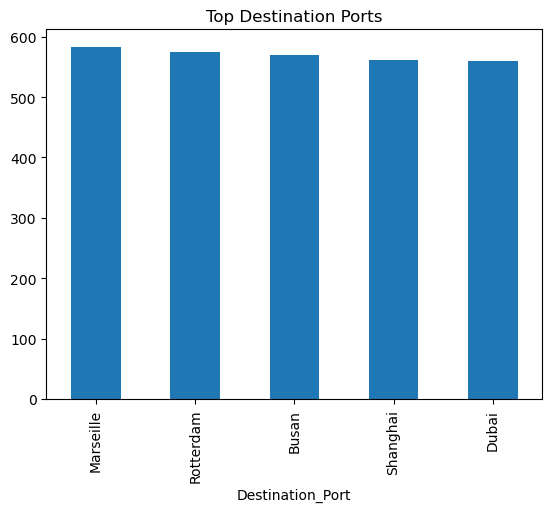

In [31]:
df['Destination_Port'].value_counts().head(5).plot(kind='bar')
plt.title("Top Destination Ports")
plt.show()

# Lead Time Vs Disruption

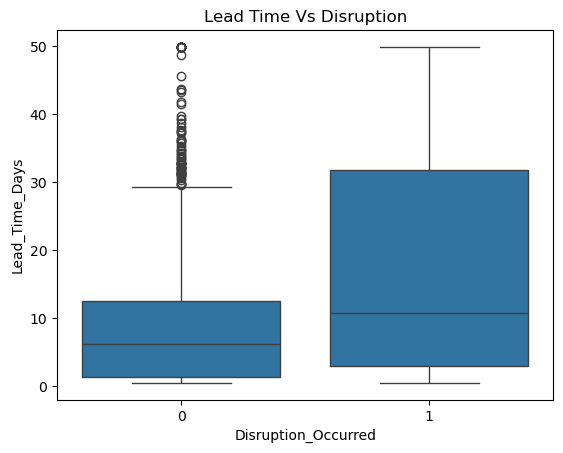

In [39]:
sns.boxplot(data=df, x='Disruption_Occurred', y='Lead_Time_Days')
plt.title("Lead Time Vs Disruption")
plt.show()

- **Lead Time (Days)** represents the actual time taken for delivery.

- The chart shows that delivery time is **significantly lower when no disruptions occur**.

# Monthly Trends

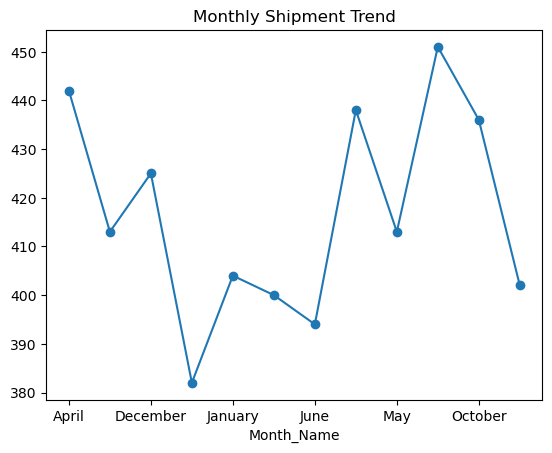

In [23]:
monthly = df.groupby('Month_Name')['Shipment_ID'].count()
monthly.plot(kind='line', marker='o')
plt.title("Monthly Shipment Trend")
plt.show()

- There is a **clear decreasing trend** in the number of shipments from **April to mid-December**.

- After mid-December, the trend **reverses**, showing a **steady increase in shipments**.

# Disruption Over Time

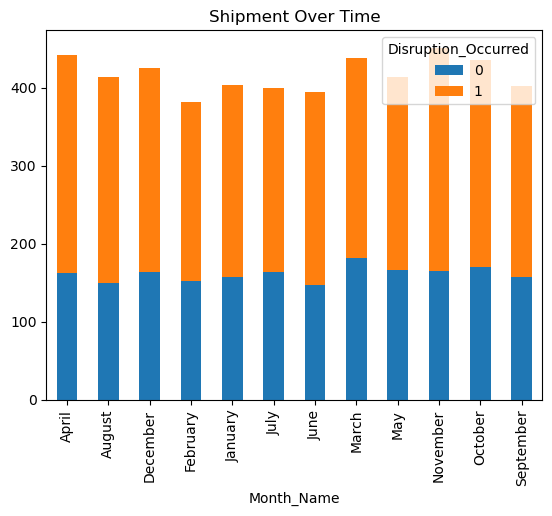

In [35]:
disruption_trend = df.groupby('Month_Name')['Disruption_Occurred'].value_counts().unstack()
disruption_trend.plot(kind='bar', stacked=True)
plt.title("Shipment Over Time")
plt.show()

The blue section (0) represents shipments that went smoothly, while the orange section (1) represents shipments that faced disruptions.
We can see that disruptions happen consistently every month, with some months like March, April, and October having slightly higher disruption counts.
Overall, there are more disrupted shipments than smooth ones in most months, indicating that supply chain disruptions are a significant concern throughout the year.

# Risk Score Distribution

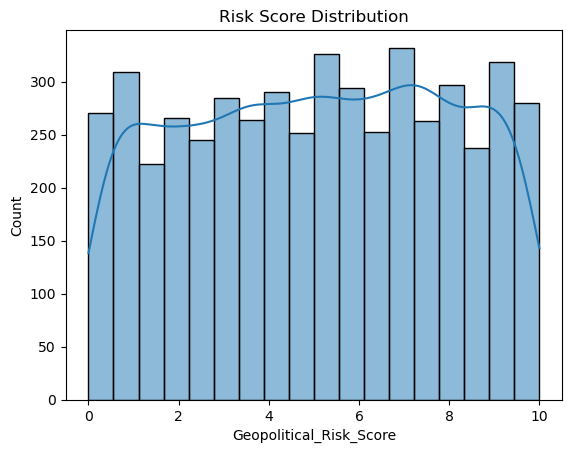

In [36]:
sns.histplot(df['Geopolitical_Risk_Score'], kde=True)
plt.title("Risk Score Distribution")
plt.show()

This plot shows the distribution of shipments across different Geopolitical Risk Scores.
Most shipments occur in the mid-range scores like around 2–8 that indicating the majority of shipments operate under moderate geopolitical risk. 
The smooth line (KDE) shows the overall trend and it is suggesting a fairly.

# Risk vs Disruption

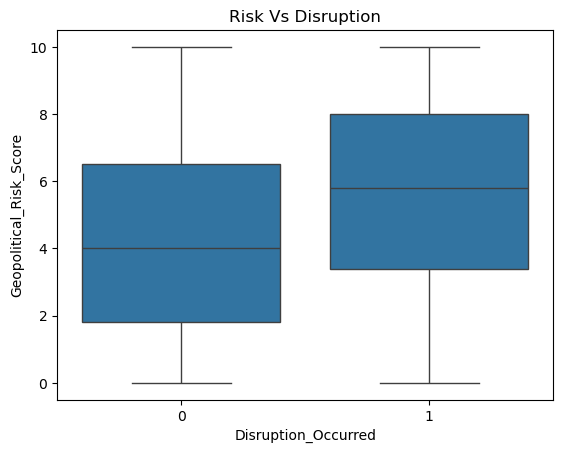

In [37]:
sns.boxplot(data=df, x='Disruption_Occurred', y='Geopolitical_Risk_Score')
plt.title("Risk Vs Disruption")
plt.show()

This boxplot compares geopolitical risk scores for cases with no disruption (0) and cases where a disruption occurred (1). When a disruption occurs, both the median risk score and the overall spread are higher by indicating that disruptions are generally associated with greater geopolitical risk. In contrast, non‑disruption cases tend to have lower and more concentrated risk scores.

# Logistics Efficiency Insights

a) Carrier Reliability Impact

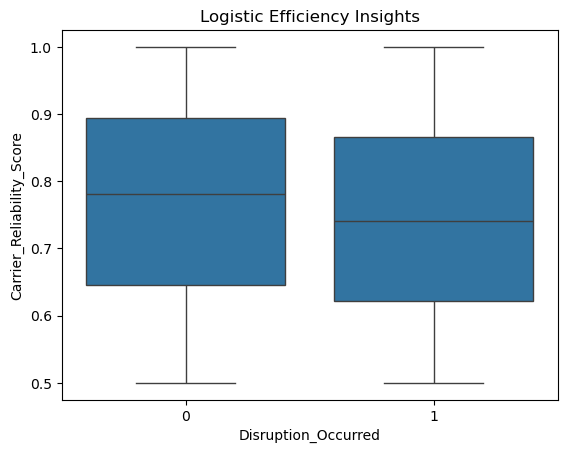

In [38]:
sns.boxplot(data=df, x='Disruption_Occurred', y='Carrier_Reliability_Score')
plt.title("Logistic Efficiency Insights")
plt.show()

The boxplot shows that shipments handled by carriers with higher reliability scores are slightly less likely to experience disruptions. While the median reliability is higher for shipments without disruptions, the overall range of scores is similar across both groups. This suggests that carrier reliability has a modest but noticeable impact on disruption occurrence.